In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("train.csv")

# Display the first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Select the input features
X = df[["GrLivArea", "BedroomAbvGr", "FullBath"]]

# Select the target variable
y = df["SalePrice"]

# Display the first 5 rows of input features
print("Input Features:")
display(X.head())

# Display the first 5 target values
print("Target Variable:")
display(y.head())

Input Features:


,GrLivArea,BedroomAbvGr,FullBath
0,1710,3,2
1,1262,3,2
2,1786,3,2
3,1717,3,1
4,2198,4,2


Target Variable:


,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


In [4]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display the shape of each dataset
print("Training input data:", X_train.shape)
print("Testing input data:", X_test.shape)
print("Training target data:", y_train.shape)
print("Testing target data:", y_test.shape)

Training input data: (1168, 3)
Testing input data: (292, 3)
Training target data: (1168,)
Testing target data: (292,)


In [5]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [6]:
# Predict house prices using the test data
y_pred = model.predict(X_test)

# Display the first 10 predicted prices
print("Predicted House Prices:")
print(y_pred[:10])

Predicted House Prices:
[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004 121157.48079629 205577.98056584 183787.20378269
 121157.48079629 147219.22233196]


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

# Display the results
print("Model Evaluation Results")
print("------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation Results
------------------------
Mean Absolute Error (MAE): 35788.061292436294
Mean Squared Error (MSE): 2806426667.247853
Root Mean Squared Error (RMSE): 52975.71771338122
R² Score: 0.6341189942328371


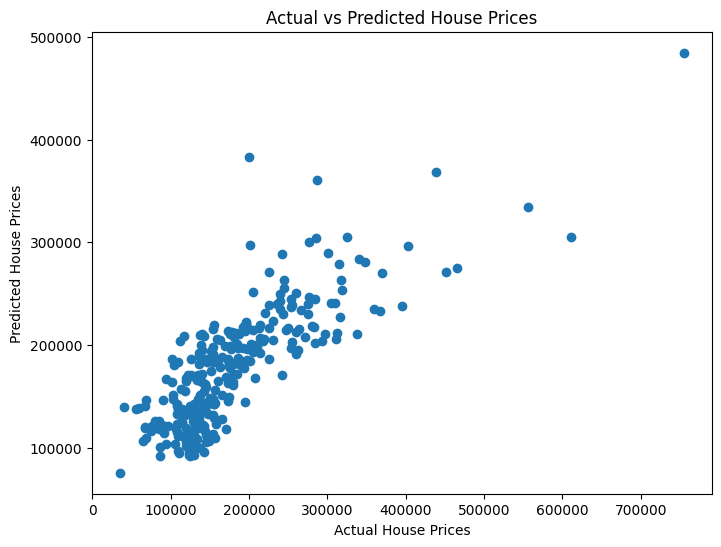

In [8]:
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()